# COMP2002 Assessment 2 -
## Sunchoeh Prince
## Part 1 - Machine Learning

Using the `e1_nutrients.csv` dataset to predict nitrite (`NITRITE`) using the other variables in the dataset. The models used are Linear Regression, Random Forest, and Neural Network. Their performance is compared using cross-validated mean squared error.



Please make sure that the data folder contains the dataset






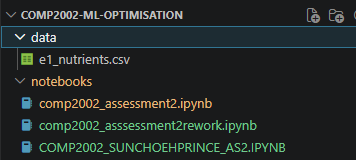

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import random

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

In [17]:
#read the csv file into a pandas dataframe
df = pd.read_csv("../data/e1_nutrients.csv")

#display the first 5 rows of the dataframe
display(df.head())

#print information about the dataframe
df.info()

#display descriptive statistics of the dataframe
display(df.describe())

#print the number of missing values in each column
print(df.isna().sum())

,Depth,NITRITE,NITRATE+NITRITE,AMMONIA,SILICATE,PHOSPHATE
0,0,0.03,0.38,0.00,1.27,0.06
1,10,0.03,0.45,0.98,1.14,0.06
2,20,0.23,2.08,1.10,2.54,0.27
3,30,0.04,0.39,0.00,1.15,0.08
4,40,0.28,2.19,1.11,2.59,0.19


<class 'pandas.DataFrame'>
RangeIndex: 2496 entries, 0 to 2495
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Depth            2496 non-null   int64  
 1   NITRITE          2496 non-null   float64
 2   NITRATE+NITRITE  2496 non-null   float64
 3   AMMONIA          2496 non-null   float64
 4   SILICATE         2496 non-null   float64
 5   PHOSPHATE        2496 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 117.1 KB


,Depth,NITRITE,NITRATE+NITRITE,AMMONIA,SILICATE,PHOSPHATE
count,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000,2496.000000
mean,26.919071,0.210601,2.905465,0.519247,1.939455,0.290741
std,19.729713,0.328292,2.260390,0.654011,1.076337,0.175216
min,0.000000,0.000000,0.000000,0.000000,0.040000,0.000000
25%,10.000000,0.040000,0.430000,0.100000,1.010000,0.160000
50%,30.000000,0.110000,3.030000,0.240000,2.080000,0.300000
75%,40.000000,0.230000,4.972500,0.640000,2.750000,0.410000
max,60.000000,2.900000,8.350000,4.170000,8.820000,2.560000


Depth              0
NITRITE            0
NITRATE+NITRITE    0
AMMONIA            0
SILICATE           0
PHOSPHATE          0
dtype: int64


## Data preparation

The dataset was loaded into Python using pandas and checked using `head()`, `info()`, `describe()`, and `isna().sum()`. This showed me that all the variable that were numeric and there wee no missing values. No imputation is needed

The target variable for prediction is 'nitrate', while the remaining columns are used as input features. Standardistion is being used for Linear Regression and the Neural Network becauase these models are more sensitive to the scale of the input date. Random Forest doesn't require scaling in the same way because it is a tree-based model.

In [3]:
#separate the inputs and targets
X = df.drop(columns=["NITRITE"])
y = df["NITRITE"]

#create a KFold object with 5 splits, shuffling the data and setting a random state for reproducibility
cv = KFold(n_splits=5, shuffle=True, random_state=42)

#model building
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    
    "Neural Network": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(50, 25),
            max_iter=3000,
            random_state=42
        ))
    ])
}

In [4]:
#EVALUATION OF MODELS USING CROSS VALIDATION
results = []

for name, model in models.items():
    scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_squared_error"
    )
    
    results.append({
        "Model": name,
        "Mean MSE": scores.mean(),
        "Std MSE": scores.std()
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,Mean MSE,Std MSE
0,Linear Regression,0.095249,0.009400
1,Random Forest,0.052304,0.011014
2,Neural Network,0.066714,0.009636


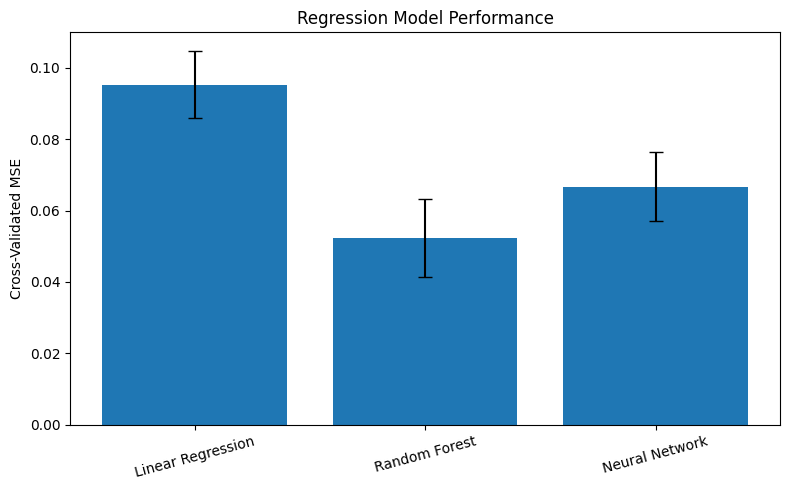

In [5]:
#PLOTTING RESULTS
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["Mean MSE"], yerr=results_df["Std MSE"], capsize=5)
plt.ylabel("Cross-Validated MSE")
plt.title("Regression Model Performance")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Regression analysis

The regression results above show that the Random FOREST Model achieved the lowest mean cross-validation mean squared error, this sugguests that it was the most accurate predictor of the 3 for nitrate values on this dataset. The Neural Ntwork preformed better than the Linear Regression, but it still had the higher average error than Random Forest.

This suggests that the reglationship between the predictor variables and the nnitrate is not purely linear, and that a model able to capture more complex patterns is more suitable. The standard deviation vlaues were also small, meaning tha the models were reasonably consistent accross the different validation folds. Overall, Random Firest appears to be the best model for the dataset due to the fact it producted the lowest prediction erroe while remaining stable while cross-validation

In [6]:
#DEMO OF PREDICTIONS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test[:5])
    
    print(name)
    print("Predictions:", preds)
    print("True values:", y_test.iloc[:5].values)
    print()

Linear Regression
Predictions: [0.05170578 0.05131972 0.23181563 0.18182822 0.26940071]
True values: [0.   0.   0.17 0.19 2.61]

Random Forest
Predictions: [0.0000e+00 3.0000e-04 1.9555e-01 1.2605e-01 1.3947e+00]
True values: [0.   0.   0.17 0.19 2.61]

Neural Network
Predictions: [ 0.00963558 -0.01474953  0.09517791  0.14356181  0.60767818]
True values: [0.   0.   0.17 0.19 2.61]



# Part 2 - Optimisation

Below is the McCormick function optimisation. The goal is the minimise the function using two different optimisation methods:

Hillclimber

Population-based Evolutionary Algorithm

## Optimisation setup

The McCormick function is used as the fitness function for this task. Random solutions are first generated in the range `-5` to `5` for both decision variables, which allows the search space to be visualised before applying the optimisation algorithms.

In [7]:
# optimisation
def mccormick(x, y):
    return math.sin(x + y) + (x - y)**2 - 1.5*x + 2.5*y + 1

In [8]:
#GENERATE RANDOM SOLUTIONS TO TEST OPTIMISATION
random.seed(42) # set the random seed for reproducibility
np.random.seed(42) # set the random seed for numpy as well

points = np.array([
    [random.uniform(-5, 5), random.uniform(-5, 5)]
    for _ in range(500) # generate 500 random solutions
])

fitness = np.array([mccormick(x, y) for x, y in points])

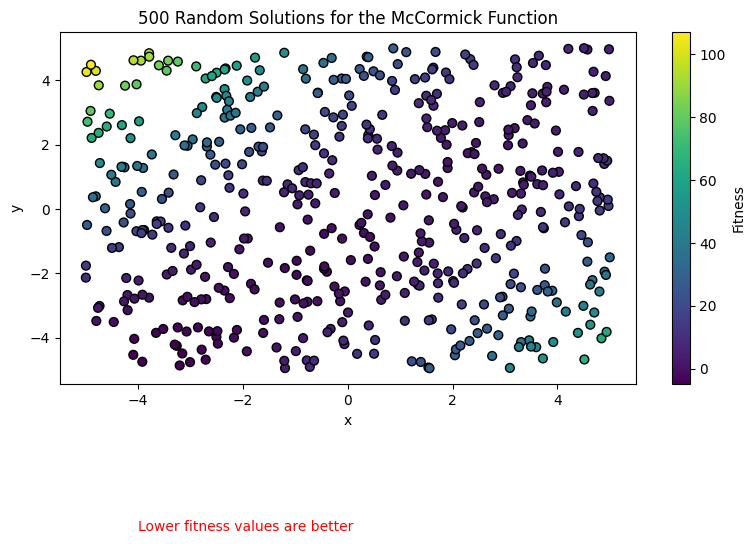

In [9]:
# plot the x and y values and colour the solutions according to their fitness value
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    points[:, 0], points[:, 1],
    c=fitness,
    cmap="viridis",
    s=40,
    edgecolor="black"
)

plt.colorbar(scatter, label="Fitness")
plt.xlabel("x")
plt.ylabel("y")
plt.title("500 Random Solutions for the McCormick Function")
plt.text(-4, -10, "Lower fitness values are better", fontsize=10, color="red")
plt.tight_layout()
plt.show()

The scatter plot shows the spread of 500 randomly generated solutions across the search space. The colours represent the fitness values of the solutions based on the McCormick function. Lower fitness values is better due to the aim being minimisation.

In [10]:
# mutation operator that performs additive gaussian mutation
def gaussian_mutation(solution, sigma=0.2, lower=-5, upper=5):
    child = solution + np.random.normal(0, sigma, size=2)
    child = np.clip(child, lower, upper)
    return child

# HILLCLIMBER ALGORITHM

In [11]:
#HILLCLIMBER ALGORITHM
def hillclimber(iterations=200, sigma=0.2, lower=-5, upper=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    parent = np.array([
        random.uniform(lower, upper),
        random.uniform(lower, upper)
    ])

    parent_fitness = mccormick(parent[0], parent[1])
    fitness_history = [parent_fitness]

    for _ in range(iterations):
        child = gaussian_mutation(parent, sigma=sigma, lower=lower, upper=upper)
        child_fitness = mccormick(child[0], child[1])

        if child_fitness < parent_fitness:
            parent = child
            parent_fitness = child_fitness

        fitness_history.append(parent_fitness)

    return parent, parent_fitness, fitness_history

In [12]:
#RUNNING THE HILLCLIMBER
best_solution_hc, best_fitness_hc, history_hc = hillclimber()

print("Best solution found by hillclimber:", best_solution_hc)
print("Best fitness found by hillclimber:", best_fitness_hc)

Best solution found by hillclimber: [-0.54391197 -1.56531663]
Best fitness found by hillclimber: -1.9126697921707816


# POPULATION BASED EVOLUTIONARY ALGORITHM

In [13]:
#POPULATION BASED EVOLUTIONARY ALGORITHM
def evolutionary_algorithm(pop_size=20, generations=200, sigma=0.2, lower=-5, upper=5, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    parents = np.array([
        [random.uniform(lower, upper), random.uniform(lower, upper)]
        for _ in range(pop_size)
    ])

    parent_fitness = np.array([
        mccormick(x, y) for x, y in parents
    ])

    fitness_history = [parent_fitness.min()]

    for _ in range(generations):
        children = np.array([
            gaussian_mutation(parent, sigma=sigma, lower=lower, upper=upper)
            for parent in parents
        ])

        child_fitness = np.array([
            mccormick(x, y) for x, y in children
        ])

        combined_population = np.vstack((parents, children))
        combined_fitness = np.concatenate((parent_fitness, child_fitness))

        best_indices = np.argsort(combined_fitness)[:pop_size]

        parents = combined_population[best_indices]
        parent_fitness = combined_fitness[best_indices]

        fitness_history.append(parent_fitness.min())

    best_index = np.argmin(parent_fitness)

    return parents[best_index], parent_fitness[best_index], fitness_history

In [14]:
#RUNNING THE EVOLUTIONARY ALGORITHM
best_solution_ea, best_fitness_ea, history_ea = evolutionary_algorithm()

print("Best solution found by evolutionary algorithm:", best_solution_ea)
print("Best fitness found by evolutionary algorithm:", best_fitness_ea)

Best solution found by evolutionary algorithm: [-3.69572095 -4.68890039]
Best fitness found by evolutionary algorithm: -5.054747651212645


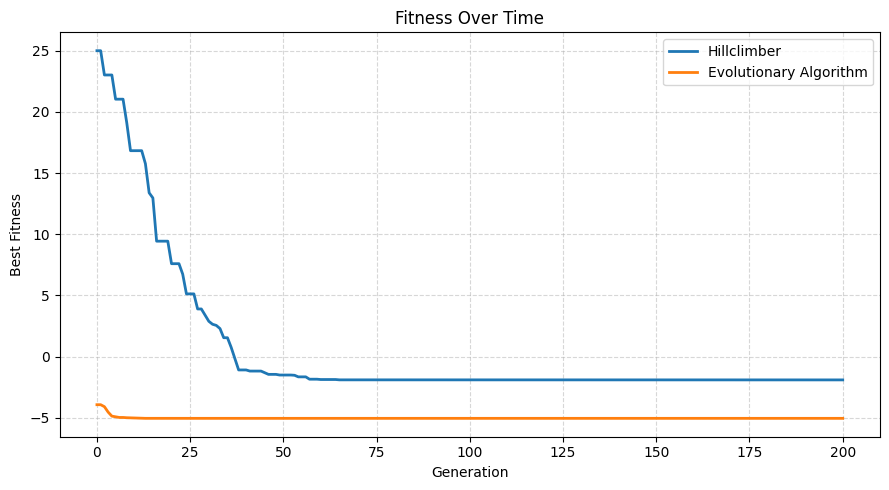

In [15]:
# PLOT COMPARING THE CHANGE IN FITNESS OVER THE RUNTIME OF THE ALGORITHMS
plt.figure(figsize=(9, 5))

plt.plot(history_hc, label="Hillclimber", linewidth=2)
plt.plot(history_ea, label="Evolutionary Algorithm", linewidth=2)

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Fitness Over Time")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Optimisation analysis

Above is the plot comparing the change in fitness over the runtim of the alrogrithms.

The hillclimber algroithm improved the starting solution by repeatdly accepting only mutated solutions with ab etter fintess value, hence forcing steading progress. Downside to this is that it only searches from one current solution, so in the case where mutations can no longer improve, it becomes stuck and no longer can improve the result.


The evolutionary algrorithm preformed better than due to utilising a method of multitasking by creatinga population of candidate solutions rather than a single entity. By mutating all parent solutions, combining the parent and child solutions, and selecting only the best solutions for the next generation, it explored the search space more effectively than Hillclimber. 

In the comparision plot, the evolutionary plot reached a lower best fitness than the hillclimber, suggesting that the population-based method was more effective for minimising the McCormick function.

## Conclusion

Overall, the machine learning reuslts showed that Random Forest was the most effective model for predicting 'nitrate' in the dataset provdded. This is due to achiving the lowest cross-validated mean squared error compared to the other models.

In optimisation, both algrotihsm improved their solutions over time. However, the population based evolutionary based algorithm achieved a better final fitness comapred to Hillclimber. This shows a broader searh throough a populiaton (evolutionary-based algorithm) can be more effective than the local search alone (hillclimbeer) for this specific problem.